# EmailAgent案例

## 1. 需求分析
首先，我们需要弄清楚Email Friend这个agent的功能和实现思路。

### 1.1 功能特性
Email Friend包含以下核心功能：
- 邮箱认证授权
- 读写邮件
- 邮件操作的人工确认
- 多会话管理
- 基于sse的异步通信

当然，这里的邮箱认证授权、读写操作都是基于Tool模拟的，并非真实操作。目的是通过案例让大家掌握与LangChain的Agent开发相关技能。

通过这个案例希望大家掌握以下技能：
- LangChain中Runtime的使用
- LangChain的中间件使用
  - 利用中间件实现动态提示词
  - 利用中间件实现动态工具选择
- LangChain中agent的异步调用

### 1.2 预期效果
用户首次访问时需要做认证授权，否则无法进行邮箱操作：
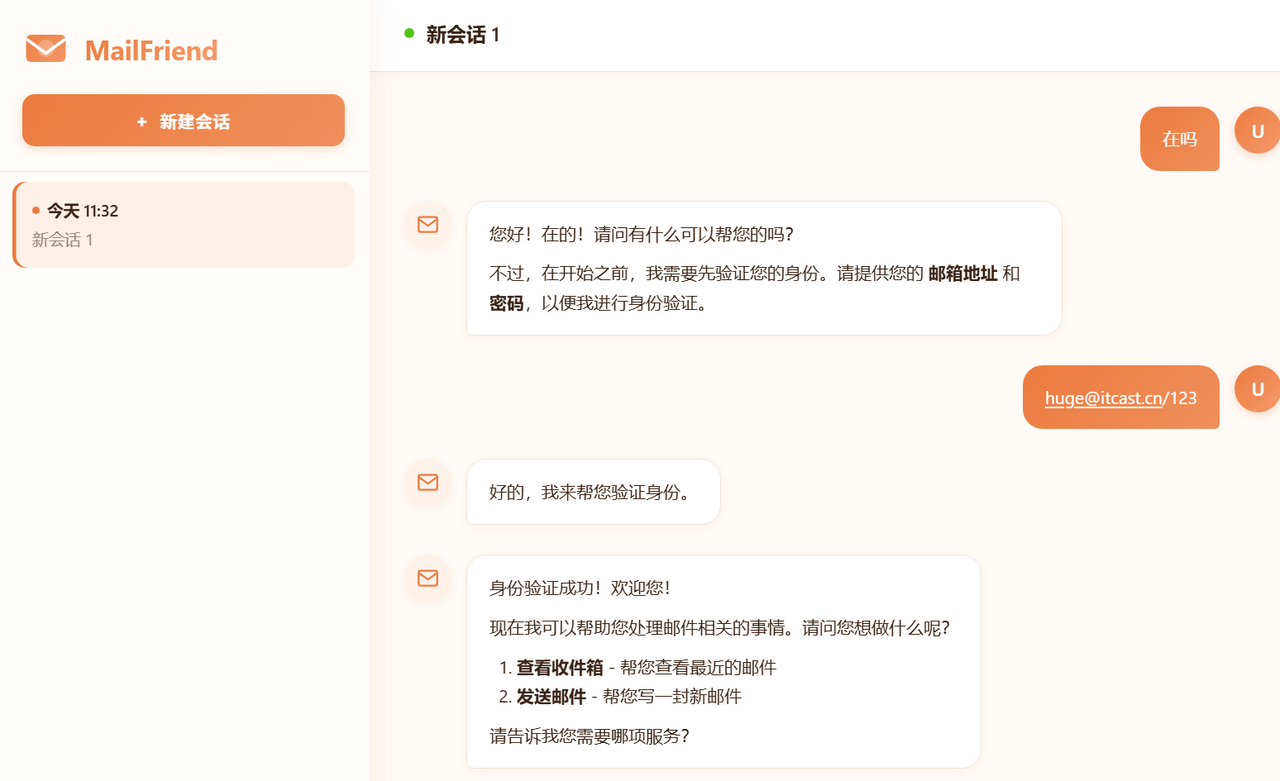
读取邮件：
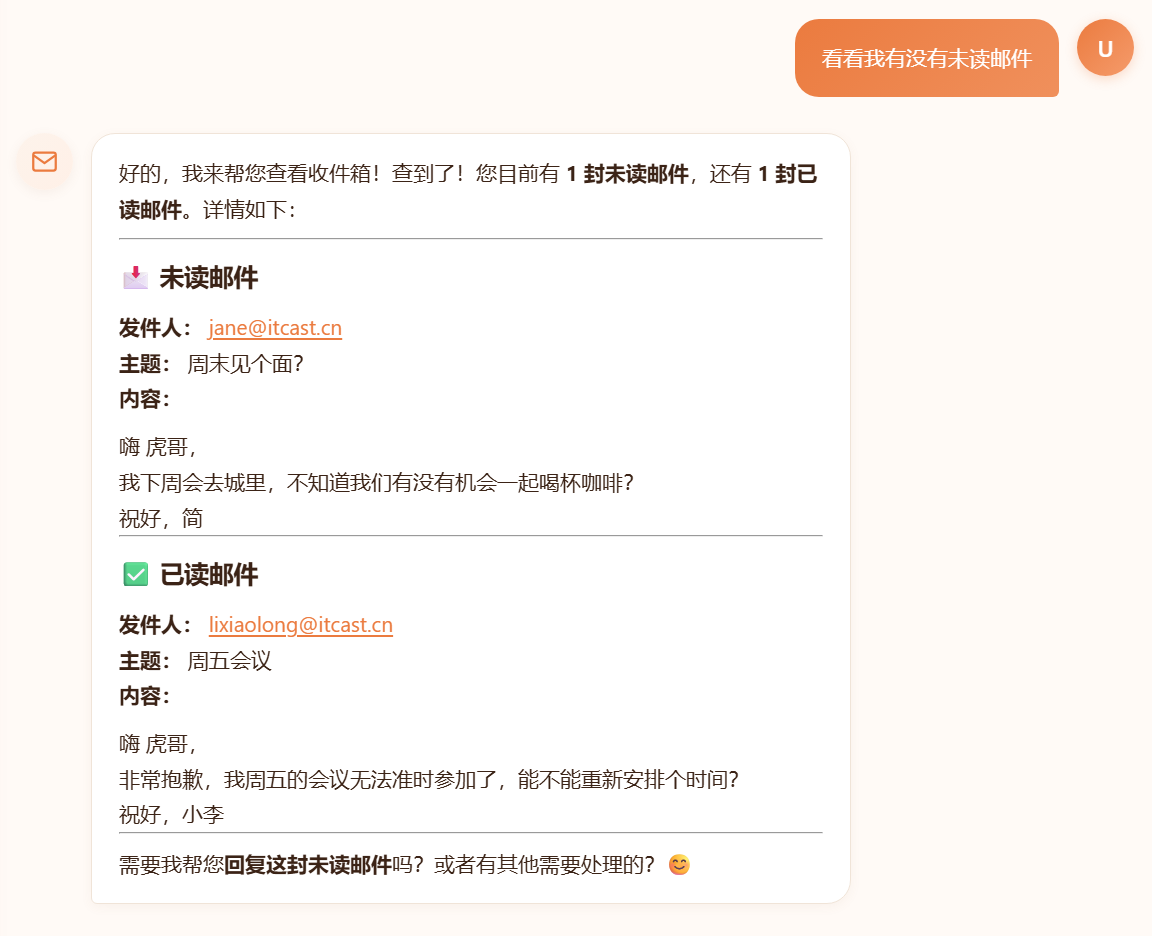
帮忙回复邮件：
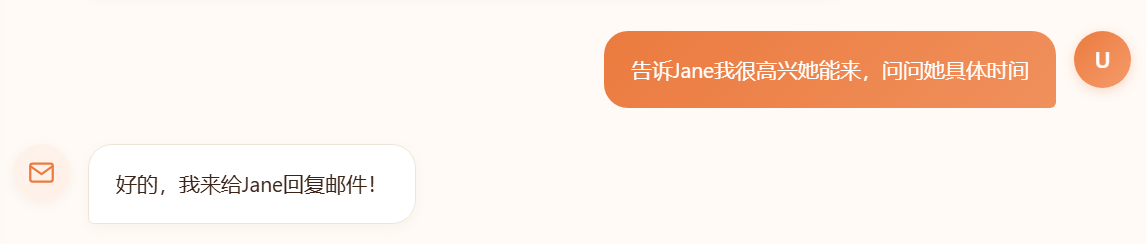
但需要经过人工确认：
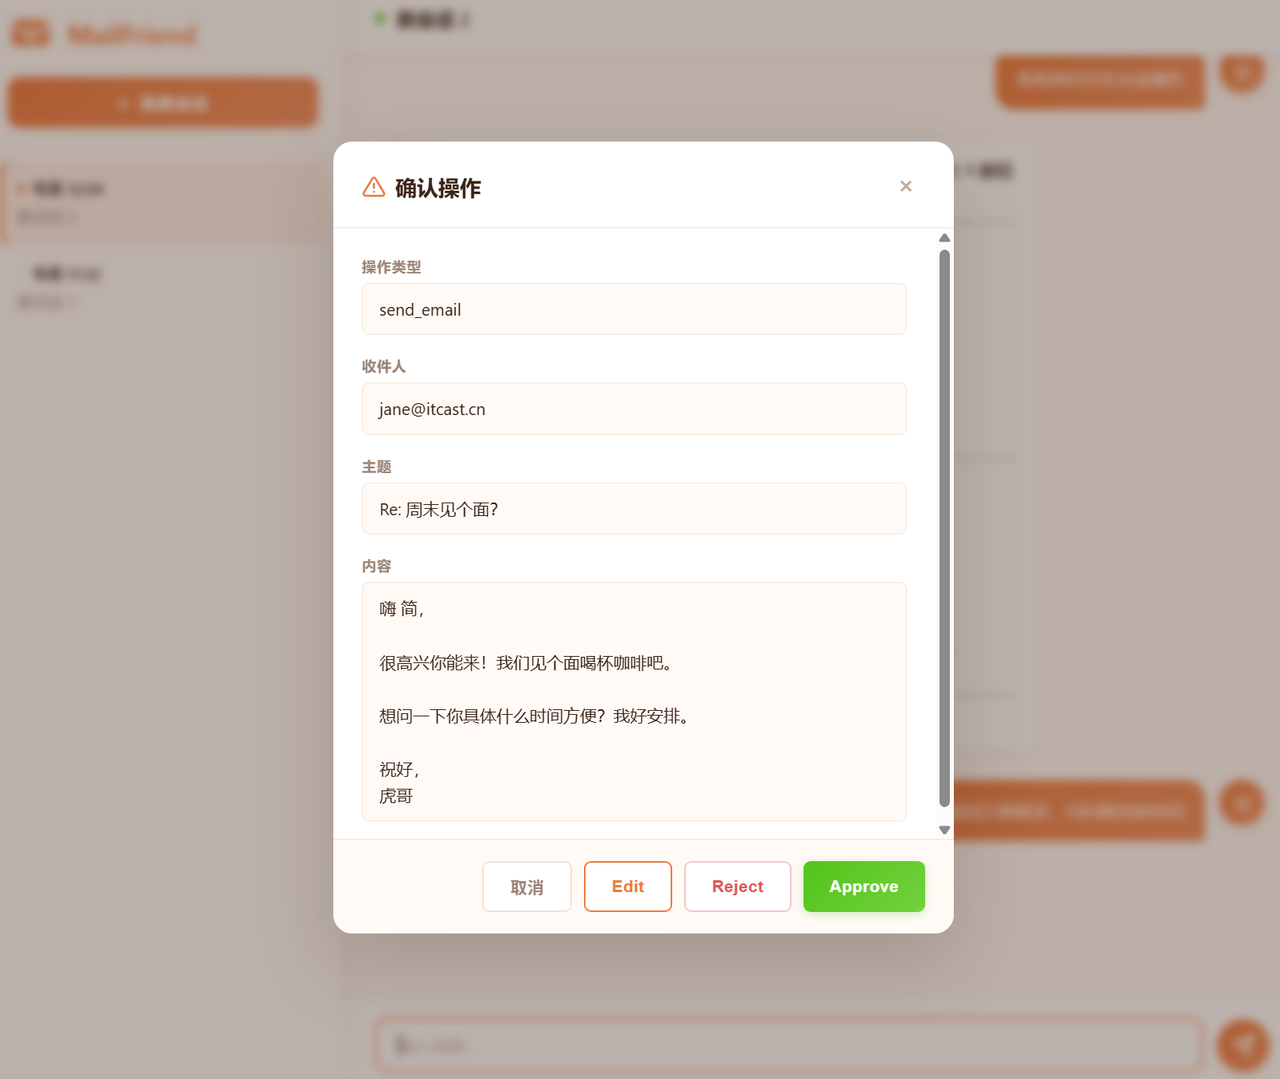
确认之后，邮件发送成功：
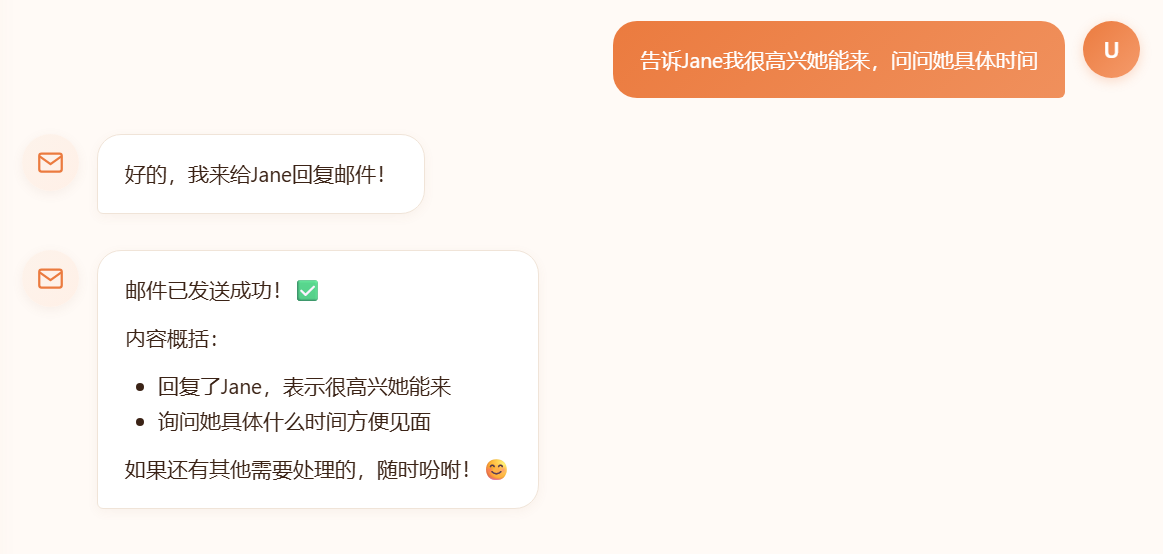

### 1.3 实现思路分析
之前说过，定义Agent的关键有三部分：
- 模型
- 工具
- 记忆

这个案例不包含多模态内容，我们可以直接使用文本模型。

工具需要定义3个：
- 邮箱鉴权工具
- 查看邮件工具
- 发送邮件工具

记忆，这里我们只需要短期记忆，也就是state，但不能仅仅是message信息，还应该包含用户的鉴权状态。所以我们应该自定义state，包含两个信息：
- messages：会话历史
- authenticated：鉴权状态

另外，为了保证Agent在完成用户鉴权之前不做邮箱等其它操作，我们需要两个不同的系统提示词
- 鉴权提示词：authenticated为False时使用，告知AI核心工作是完成鉴权，否则不能做其它事情
- 邮箱助手提示词：authenticated为True时使用，告知AI核心工作是操作邮箱
然后，我们需要通过中间件实现动态提示词。

与之类似，虽然工具有3个，但为了减少发送给AI的参数信息，我们也分为两种情况：
- 当authenticated为False时：仅提供邮箱鉴权工具
- 当authenticated为True时：仅提供查看邮件、发送邮件工具

## 2. 功能模拟
接下来，我们依然先使用Jupyter来模拟调试功能。

我们先导入各种所需的依赖：

In [1]:
from langchain.agents import create_agent
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.tools import tool, ToolRuntime
from langchain.agents import AgentState
# 加载环境变量
from dotenv import load_dotenv

load_dotenv()

True

### 2.1 state
首先，我们要定义一个state，记录用户邮箱授权状态：

In [2]:
# state信息，记录用户是否授权邮箱操作
class AuthenticatedState(AgentState):
    authenticated: bool

### 2.2 tool
接着，我们定义3个工具：
- authenticate : 用来模拟用户邮箱鉴权
- check_inbox : 模拟收取邮件
- send_email : 模拟发送邮件

邮箱鉴权工具：

In [3]:
from langchain_protocol import Command


# 定义工具，用于用户邮箱鉴权
@tool
def authenticate(email: str, password: str, runtime: ToolRuntime) -> Command:
    """Authenticate the user with the given email and password"""

    # 定义变量，记录校验结果
    authenticated = False
    message = "Authentication failed"

    # 校验邮箱和密码
    if email == "huge@itcast.cn" and password == "123":
        authenticated = True
        message = "Successfully authenticated"

    # 返回校验结果
    return Command(
            update={
                "authenticated": authenticated,
                "messages": [
                    ToolMessage(message, tool_call_id=runtime.tool_call_id)
                ],
            }
        )

邮箱操作工具：

In [4]:
# 定义工具，收取和发送邮件
@tool
def check_inbox() -> str:
    """Read an email from the given address."""
    # 模拟收件箱邮件
    return [
        {
            "subject": "周末见个面？",
            "content": """
                嗨 虎哥，
                我下周会去城里，不知道我们有没有机会一起喝杯咖啡？

                祝好，简
            """,
            "from": "jane@itcast.cn",
            "status": "unread"
        },
        {
            "subject": "周五会议",
            "content": """
                嗨 虎哥，
                非常抱歉，我周五的会议无法准时参加了，能不能重新安排个时间？

                祝好，小李
            """,
            "from": "lixiaolong@itcast.cn",
            "status": "checked"
        }
    ]


@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an response email"""
    return f"邮件已发送至 {to} , 主题： {subject} , 内容： {body}"

### 2.3 动态工具中间件
为了减少调用模型时传递的参数，我们通过自定义中间件实现动态工具：
- 在用户邮箱授权之前，只能看到authenticate工具
- 在用户邮箱授权之后，只能看到send_email和check_inbox工具

In [5]:
from collections.abc import Callable
from langchain.agents.middleware import ModelRequest, ModelResponse, wrap_model_call


@wrap_model_call
def dynamic_tool_call(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Allow read inbox and send email tools only if user provides correct email and password"""

    # 读取授权状态
    authenticated = request.state.get("authenticated")

    if authenticated:
        tools = [check_inbox, send_email]
    else:
        tools = [authenticate]

    # 重写工具列表
    request = request.override(tools=tools)
    return handler(request)

### 2.4 动态提示词中间件
由于业务分为两个阶段，所以每个阶段的提示词也不一样：
- 鉴权阶段：告知AI的核心工作是鉴权
- 工作阶段：告知AI的核心工作是处理邮件

In [6]:
from langchain.agents.middleware import dynamic_prompt

# 授权前，要求鉴定用户权限的系统提示词
unauthenticated_prompt = """You are a helpful email assistant.
    For system security protocols, you must authenticate user before any other interaction.
    """

# 授权后，邮件处理的系统提示词
authenticated_prompt = "You are a helpful assistant that can check the inbox and send emails."


# 在中间件中通过判断state的authenticated值来动态切换提示词
@dynamic_prompt
def dynamic_prompt_func(request: ModelRequest) -> str:
    """Generate system prompt based on authentication status"""
    authenticated = request.state.get("authenticated")
    final_prompt = authenticated_prompt if authenticated else unauthenticated_prompt
    return final_prompt

### 2.5 Agent
最后，就是组织模型、工具、中间件，创建Agent：

In [7]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

# 初始化checkpointer
checkpointer = InMemorySaver()

agent = create_agent(
    "deepseek-chat",
    tools=[authenticate, check_inbox, send_email],
    state_schema=AuthenticatedState,
    checkpointer=checkpointer,
    middleware=[
        dynamic_tool_call,
        dynamic_prompt_func,
        HumanInTheLoopMiddleware(
            interrupt_on={
                "authenticate": False,
                "check_inbox": False,
                "send_email": True,
            }
        )
    ],
)

### 2.6 HITL的stream模式
接下来我们测试下Agent效果，这里我们选择采用stream流式调用，在之前我们都采用stream_mode为messages。
但需要注意的是，由于HITL并不是模型的能力，而是LangChain利用wrap_tool_call在模型调用工具前后的一种拦截行为。因此采用messages模式只能看到模型返回的消息，无法看到interrupt中断信息。

在HITL存在时，stream采用的模式比较特殊，需要同时包含两种模式：
- messages : 以token方式返回AI生成的内容
- updates : 返回Agent调用时的每个步骤的完整信息，比如当出现interrupt时，完整展示interrupt信息
同时，当我们使用的LangGraph版本大于1.1时，我们还可以设定stream的version为v2，这样返回的结果格式会以dict返回，而不是tuple，会更好处理。格式如下：
```
{
    "type": "interrupt",
    "data": Interrupt(...),
    ...
}
```
代码如下：

In [8]:
config = {"configurable" : {"thread_id": "2"}}

response = agent.stream(
    {"messages": [HumanMessage("帮我查看下邮件。")]},
    config = config,
    stream_mode= ["messages", "updates"],
    version="v2"
)

for chunk in response:
    print(f"---------------------{chunk["type"]}-----------------------")
    print(chunk["data"])

---------------------messages-----------------------
(AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019ea204-7746-7e90-b0fb-f365868d222b', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'ls_integration': 'langchain_chat_model', 'thread_id': '2', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:62a16728-66f2-bde7-c2fa-0d625cee5214', 'checkpoint_ns': 'model:62a16728-66f2-bde7-c2fa-0d625cee5214', 'ls_provider': 'deepseek', 'ls_model_name': 'deepseek-chat', 'ls_model_type': 'chat', 'ls_temperature': None})
---------------------messages-----------------------
(AIMessageChunk(content='好的', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019ea204-7746-7e90-b0fb-f365868d222b', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'ls_integration': 'lang

可以看到，我要求查看邮件，但AI并不会这么做，而是会询问我的邮箱地址和密码，要求完成授权。

### 2.7 测试
接下来，我们继续测试hitl过程
#### 2.7.1 邮箱授权
我们继续调用Agent，传递用户邮箱和密码。不过接下来打印的时候我们就可以把message类型和updates类型分开打印了：

In [9]:
from typing import Any

# 用户授权
response = agent.stream(
    {"messages": [HumanMessage("huge@itcast.cn/123")]},
    config = config,
    stream_mode= ["messages", "updates"],
    version="v2"
)

def print_chunk(chunk: dict[str, Any]):
    type = chunk["type"]
    data = chunk["data"]
    if type == "messages":
        token, metadata = data
        if isinstance(token, AIMessage) and token.content:
            print(token.content, end="", flush=True)
    elif type == "updates":
        print("")
        print("=================updates=====================")
        print(data)

for chunk in response:
    print_chunk(chunk)

好的，我来帮您验证身份。
=================updates=====================
{'model': {'messages': [AIMessage(content='好的，我来帮您验证身份。', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'model_provider': 'deepseek'}, id='lc_run--019ea205-2ebe-79e3-a52c-1be80e3d18c1', tool_calls=[{'name': 'authenticate', 'args': {'email': 'huge@itcast.cn', 'password': '123'}, 'id': 'call_00_IAfudq1jZVv0xE8G9ZfV4911', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 350, 'output_tokens': 72, 'total_tokens': 422, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}})]}}

=================updates=====================
{'HumanInTheLoopMiddleware.after_model': None}


TypeError: 'typing.Union' object is not callable

#### 2.7.2 触发Interrupt
我们继续调用Agent，让它帮我回复邮件，不过接下来打印的时候我们就可以把message类型和updates类型分开打印了：

In [ ]:
# 用户授权
response = agent.stream(
    {"messages": [HumanMessage("huge@itcast.cn/123")]},
    config = config,
    stream_mode= ["messages", "updates"],
    version="v2"
)

for chunk in response:
    print_chunk(chunk)

可以看到，虽然AI已经帮我们写了邮件，但是并没有发送，而是在调用send_email这个Tool时被拦截了，同时在updates中可以看到interrupt信息。
接下来，就可以发送到前端，让用户来做决定了。

#### 2.7.3 用户介入
接下来，用户就可以根据自己的需求来处理interrupt了，可以选择：
- Approve
- Reject
- Edit

例如，我们选择reject拒绝发送，同时告诉AI邮件内容有问题，让它改一改：

In [ ]:
# 用户处理interrupt，比如reject
response = agent.stream(
    Command(
        resume={
            "decisions": [
                {
                    "type": "reject",
                    # 告知AI拒绝的原因
                    "message": "语气太书面了，这不是工作邮件，Jane是我的好朋友，回复自然一点。"
                }
            ]
        }
    ),
    config = config,
    stream_mode= ["messages", "updates"],
    version="v2"
)

for chunk in response:
    print_chunk(chunk)

可以看到，我们reject的理由会作为ToolMessage返回给AI，AI看到后重写了一封邮件，再次尝试发送，再次触发了Interrupt

接下来，就可以再次让人工介入了。

### 2.8 会话历史
带有hitl的Agent会话历史也比较特殊，与之前的纯对话历史不同。

#### 2.8.1 checkpointer获取历史
之前我们通过checkpointer获取会话历史，但是存在一个问题，checkpointer中直接获取拿不到interrupt信息，只能拿到Message信息：
```
checkpointer.get(config)
````

#### 2.8.2 tate获取历史
如果要同时获取到历史消息、interrupt等信息，必须通过AgentState：
```
agent.get_state(config)
```

#### 2.8.3 历史消息处理
我们可以定义一个方法，专门从state中获取历史消息和Interrupt信息：

In [ ]:
def get_messages(thread_id: str) -> dict:
    """获取会话历史，如果存在中断则返回中断信息"""

    config = {"configurable": {"thread_id": thread_id}}
    state = agent.get_state(config)
    if state is None or not state.values:
        return {"messages": []}

    messages = state.values.get("messages", [])

    # 转换消息格式
    result = []
    for msg in messages:
        if not msg.content:
            continue
        if isinstance(msg, HumanMessage):
            result.append({"role": "user", "content": msg.content})
        elif isinstance(msg, AIMessage):
            result.append({"role": "assistant", "content": msg.content})

    response = {"messages": result}

    # 检查是否存在中断
    interrupts = None
    if hasattr(state, 'interrupts') and state.interrupts:
        interrupts = state.interrupts
    elif hasattr(state, 'tasks') and state.tasks:
        for task in state.tasks:
            if hasattr(task, 'interrupts') and task.interrupts:
                interrupts = task.interrupts
                break

    if interrupts:
        response["has_interrupt"] = True
        response["interrupt"] = {
            "reason": "需要人工确认",
            "details": _serialize(interrupts)
        }

    return response

def _serialize(obj):
    """递归转换对象为可 JSON 序列化的格式"""
    if hasattr(obj, 'value'):
        return _serialize(obj.value)
    elif hasattr(obj, 'model_dump'):
        return obj.model_dump()
    elif isinstance(obj, (list, tuple)):
        return [_serialize(item) for item in obj]
    elif isinstance(obj, dict):
        return {k: _serialize(v) for k, v in obj.items()}
    return obj

In [ ]:
get_messages("1")